# 14 — Forward sensitivity analysis (FSA): usage and checks

The paper trains ChemKAN with forward sensitivity analysis (p. 8). `--sensitivity fsa`
does the same here: the model state and its sensitivities are integrated **together** by
the same Tsit5 solver, and the parameter gradient is assembled from the sensitivities —
no backpropagation through the solver.

In the paper's notation (`u = [ũ, T]`, Eqs. 13–15):

| stage | integrated | sensitivity | sensitivity equation |
|---|---|---|---|
| biodiesel, H₂ Stage 1 | `ũ` (T is an input) | `S_kin = ∂ũ/∂θ_kin` | `dS_kin/dt = (∂KAN_kin/∂ũ) S_kin + ∂KAN_kin/∂θ_kin` |
| H₂ Stage 2 | `u = [ũ, T]` | `S_g = ∂u/∂θ_g`, g ∈ {kin, thermo, cor} | `dS_g/dt = (∂f/∂u) S_g + ∂f/∂θ_g` |

with `S(t₀) = 0` and `dL/dθ = Σ_j S(t_j)ᵀ ∂L/∂u(t_j)`. Details: `chemkan/src/chemkan/ASSUMPTIONS.md` §9;
reference: SciMLSensitivity.jl, [Sensitivity Math Details](https://docs.sciml.ai/SciMLSensitivity/stable/sensitivity_math/).

The checks below are small, fast versions of the full pre-training validation, whose
record is loaded in §6.

In [1]:
%matplotlib inline
from pathlib import Path
import json, sys, time
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
for p in ("chemkan/src", "chemkan/scripts", "chemkan/scripts/fsa"):
    sys.path.insert(0, str(ROOT / p))
torch.set_num_threads(1)

import _problems as P                          # the validated problem builders (B0 / H0 / Hnorm1 tensors)
from chemkan.solver import SolverConfig, integrate
from chemkan.training import loss_and_gradients
from chemkan.fsa import FunctionalDynamics, integrate_with_sensitivities

def cfg(rtol, atol, backend):
    return SolverConfig(method="tsit5", rtol=rtol, atol=atol, sensitivity=backend)

def grad(prob, backend, rtol=1e-6, atol=1e-8):
    fd = FunctionalDynamics(prob.dynamics, prob.params)       # fixes the parameter order
    for p in prob.params: p.grad = None
    t0 = time.perf_counter()
    loss = loss_and_gradients(prob.dynamics, prob.x0, prob.t, prob.params, prob.loss_fn,
                              cfg(rtol, atol, backend))
    g = torch.cat([p.grad.reshape(-1) for p in fd.params])
    return g, float(loss.detach()), time.perf_counter() - t0, fd.packing

rel = lambda a, b: float((a - b).norm() / b.norm())

## 1. Usage

**Command line** — every trainer takes `--sensitivity {direct_autograd,fsa}`
(`direct_autograd` stays the default, so old commands are unchanged):

```bash
python chemkan/scripts/train_biodiesel.py --sensitivity fsa --run-dir results/.../fsa_seed0
python chemkan/scripts/train_hydrogen.py  --sensitivity fsa --stage1-epochs 10000 --stage2-epochs 0 --run-dir ...
python chemkan/scripts/train_hydrogen.py  --sensitivity fsa --stage1-from <FSA checkpoint_stage1.pt> --run-dir ...
```

A Stage-2 run refuses a Stage-1 checkpoint trained with the other backend, and
`--resume` refuses to switch backend. Evaluating an FSA-trained checkpoint is the
ordinary state-only solve.

**Library** — one call forms the loss and puts `dL/dθ` in `.grad`, for either backend.
Here on the trained B0 biodiesel model in float32 at the production tolerance:

In [2]:
prob = P.biodiesel("trained", torch.float32)
g_da,  L_da,  s_da,  _ = grad(prob, "direct_autograd")
g_fsa, L_fsa, s_fsa, _ = grad(prob, "fsa")
print(f"loss      direct autograd {L_da:.6f} | FSA {L_fsa:.6f}")
print(f"gradient  relative difference {rel(g_fsa, g_da):.2e}   cosine {float(g_fsa @ g_da / (g_fsa.norm() * g_da.norm())):.8f}")
print(f"seconds   direct autograd {s_da:.2f} | FSA {s_fsa:.2f}")

loss      direct autograd 0.062017 | FSA 0.062016
gradient  relative difference 1.33e-06   cosine 1.00000000
seconds   direct autograd 0.20 | FSA 1.64


## 2. Analytic check: `dy/dt = θy`

Not a ChemKAN problem — it tests the generic machinery on a case with a known answer:
`y = y₀e^{θt}`, so `S = ∂y/∂θ = t·y(t)`. Errors should shrink as the tolerance tightens.

rtol 1e-06:  max rel. error  y 8.1e-07   S 2.2e-06   S(t0) = 0.0
rtol 1e-08:  max rel. error  y 2.3e-08   S 6.0e-08   S(t0) = 0.0


rtol 1e-10:  max rel. error  y 5.9e-10   S 1.5e-09   S(t0) = 0.0


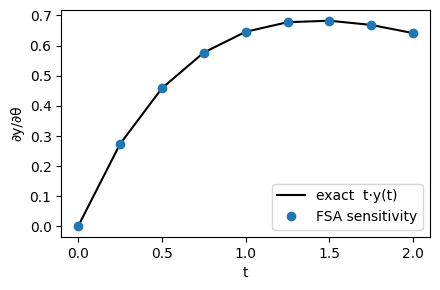

In [3]:
class Exp(torch.nn.Module):
    def __init__(self, theta):
        super().__init__(); self.theta = torch.nn.Parameter(torch.tensor(theta, dtype=torch.float64))
    def forward(self, t, y):
        return self.theta * y

theta, y0 = -0.7, 1.3
t = torch.linspace(0, 2, 9, dtype=torch.float64)
dyn = Exp(theta)
y_ex = y0 * torch.exp(theta * t)
for rtol, atol in ((1e-6, 1e-8), (1e-8, 1e-10), (1e-10, 1e-12)):
    y, S = integrate_with_sensitivities(FunctionalDynamics(dyn, [dyn.theta]),
                                        torch.tensor([[y0]], dtype=torch.float64), t, cfg(rtol, atol, "fsa"))
    print(f"rtol {rtol:.0e}:  max rel. error  y {float(((y[:,0,0]-y_ex)/y_ex).abs().max()):.1e}"
          f"   S {float(((S[1:,0,0,0]-t[1:]*y_ex[1:])/(t[1:]*y_ex[1:])).abs().max()):.1e}   S(t0) = {float(S[0].abs().max())}")

plt.figure(figsize=(4.5, 3))
plt.plot(t, t * y_ex, "k-", label="exact  t·y(t)")
plt.plot(t, S[:, 0, 0, 0], "o", label="FSA sensitivity")
plt.xlabel("t"); plt.ylabel("∂y/∂θ"); plt.legend(); plt.tight_layout()

## 3. FSA differentiates the same equations the solver integrates

The Jacobians come from `torch.func` applied to the **existing** dynamics wrapper (same
normalizer, temperature provider and model code). Its output must equal the wrapper's,
here for the three stage types:

In [4]:
for name, prob in (("biodiesel",        P.biodiesel("trained")),
                   ("H2 Stage 1",       P.stage1("trained", idx=P.H2_SUBSET)),
                   ("H2 Stage 2 (Hnorm1 final)", P.stage2("Hnorm1-final", idx=P.H2_SUBSET))):
    fd = FunctionalDynamics(prob.dynamics, prob.params)
    with torch.no_grad():
        F_wrap, F_func = prob.dynamics(prob.t[10], prob.x0), fd.rhs(prob.t[10], prob.x0)
    print(f"{name:28s} max |difference| / max |rate| = {float((F_func-F_wrap).abs().max()/F_wrap.abs().max()):.1e}   (float64)")

biodiesel                    max |difference| / max |rate| = 5.2e-16   (float64)
H2 Stage 1                   max |difference| / max |rate| = 2.5e-17   (float64)
H2 Stage 2 (Hnorm1 final)    max |difference| / max |rate| = 5.6e-15   (float64)


## 4. FSA vs direct autograd on ChemKAN, per parameter group

Same fixed model, same data, loss and solver; float64. The two backends use different
adaptive steps, so they need not agree bitwise — they must **converge to each other** as
the tolerance tightens. Stage 2 uses the norm-matched (Hnorm1) initial model at the
representative 1050 K / φ = 0.9 condition, which ignites.

In [5]:
rows = []
for name, prob in (("biodiesel (B0 trained)", P.biodiesel("trained")),
                   ("H2 Stage 2 (Hnorm1 init, 1050 K)", P.stage2("Hnorm1-init", idx=(14,)))):
    for rtol, atol in ((1e-6, 1e-8), (1e-8, 1e-10), (1e-10, 1e-12)):
        gd, _, sd, pk = grad(prob, "direct_autograd", rtol, atol)
        gf, _, sf, _ = grad(prob, "fsa", rtol, atol)
        row = {"problem": name, "rtol": rtol, "all parameters": rel(gf, gd)}
        for grp, ix in pk.group_indices().items():
            row[grp] = rel(gf[ix], gd[ix])
        row["s DA / FSA"] = f"{sd:.1f} / {sf:.1f}"
        rows.append(row)
pd.set_option("display.float_format", "{:.1e}".format)
pd.DataFrame(rows).fillna("—")

,problem,rtol,all parameters,theta_kin,s DA / FSA,theta_thermo,theta_cor
0,biodiesel (B0 trained),1.0e-06,1.8e-06,1.8e-06,0.1 / 0.6,—,—
1,biodiesel (B0 trained),1.0e-08,5.4e-08,5.4e-08,0.4 / 2.6,—,—
2,biodiesel (B0 trained),1.0e-10,1.6e-09,1.6e-09,0.6 / 4.6,—,—
3,"H2 Stage 2 (Hnorm1 init, 1050 K)",1.0e-06,1.1e-03,1.1e-03,1.6 / 11.4,3.7e-05,2.6e-05
4,"H2 Stage 2 (Hnorm1 init, 1050 K)",1.0e-08,3.4e-07,3.4e-07,2.5 / 16.6,2.3e-07,1.8e-07
5,"H2 Stage 2 (Hnorm1 init, 1050 K)",1.0e-10,7.4e-09,7.4e-09,4.4 / 41.4,6.5e-09,5.2e-09


## 5. Trajectories stay independent

A batch shares parameters but its trajectories are separate ODEs: the rate of
trajectory *b* must not depend on the state of trajectory *c*. Exact zeros are required
(hydrogen Stage 1, each trajectory with its own observed `T_obs(t)`):

In [6]:
from torch.func import jacrev
prob = P.stage1("trained", idx=P.H2_SUBSET)
fd = FunctionalDynamics(prob.dynamics, prob.params)
J = jacrev(lambda x: fd.rhs(prob.t[20], x))(prob.x0)          # (B, n, B, n)
B = J.shape[0]
cross = max(float(J[b, :, c, :].abs().max()) for b in range(B) for c in range(B) if b != c)
own = min(float(J[b, :, b, :].abs().max()) for b in range(B))
print(f"largest cross-trajectory derivative: {cross}   (smallest own-trajectory block max: {own:.2e})")

largest cross-trajectory derivative: 0.0   (smallest own-trajectory block max: 2.21e+07)


## 6. The full validation record

Everything above is a quick re-check. The complete validation ran before any FSA
training, against acceptance criteria recorded in advance
(`results/experiments/validation/fsa/`, rendered in its `README.md`). Sections C and E
first failed a Stage-1 refinement criterion and pass under a documented amendment (the
same thresholds, one tolerance decade finer); the original results are kept.

In [7]:
V = ROOT / "results/experiments/validation/fsa"
s = json.loads((V / "summary.json").read_text())
names = {"A": "analytic problem", "B": "functional equivalence", "C": "FSA vs direct-autograd gradients",
         "D": "state consistency (augmented vs state-only)", "E": "trajectory independence",
         "F": "production dtype (float32)", "G": "finite differences (optional)"}
tab = pd.DataFrame([{"section": k, "check": names[k], "status": v["status"],
                     "original": v.get("original_status", "")} for k, v in s.items() if k in names])
extra = [("direct-autograd regression", "da_regression.json"), ("resume 10 vs 5+5", "resume_validation.json"),
         ("smoke tests", "smoke_summary.json")]
tab = pd.concat([tab, pd.DataFrame([{"section": "", "check": n, "status": json.loads((V / f).read_text())["status"],
                                     "original": ""} for n, f in extra])], ignore_index=True)
print("core validation:", s["core_validation"]); tab

core validation: PASS


,section,check,status,original
0,A,analytic problem,PASS,
1,B,functional equivalence,PASS,
2,C,FSA vs direct-autograd gradients,PASS,FAIL
3,D,state consistency (augmented vs state-only),PASS,
4,E,trajectory independence,PASS,FAIL
5,F,production dtype (float32),PASS,
6,G,finite differences (optional),INCONCLUSIVE,
7,,direct-autograd regression,PASS,
8,,resume 10 vs 5+5,PASS,
9,,smoke tests,PASS,


## 7. Training with FSA so far

Scientific FSA runs (seed 0, the baselines' saved settings; only the sensitivity backend
differs). Single-seed results — not a statement about robustness.

Top: the loss as trained (Eq. 18, summed over the observation times). Bottom: the same
curves divided by the number of observation times `N_t` (30 biodiesel, 50 hydrogen) —
a time-averaged view; the training is unchanged. Each logged value is the loss at the
weights an update started from, so the last logged value can sit on a spike and differ
from the final-checkpoint MSE in the table.

,train MSE (full trajectory),test MSE (full trajectory),training time [s]
run,,,
B0 (direct autograd),0.062017,0.081401,628.0747
B0-FSA,0.031062,0.068954,3841.6477


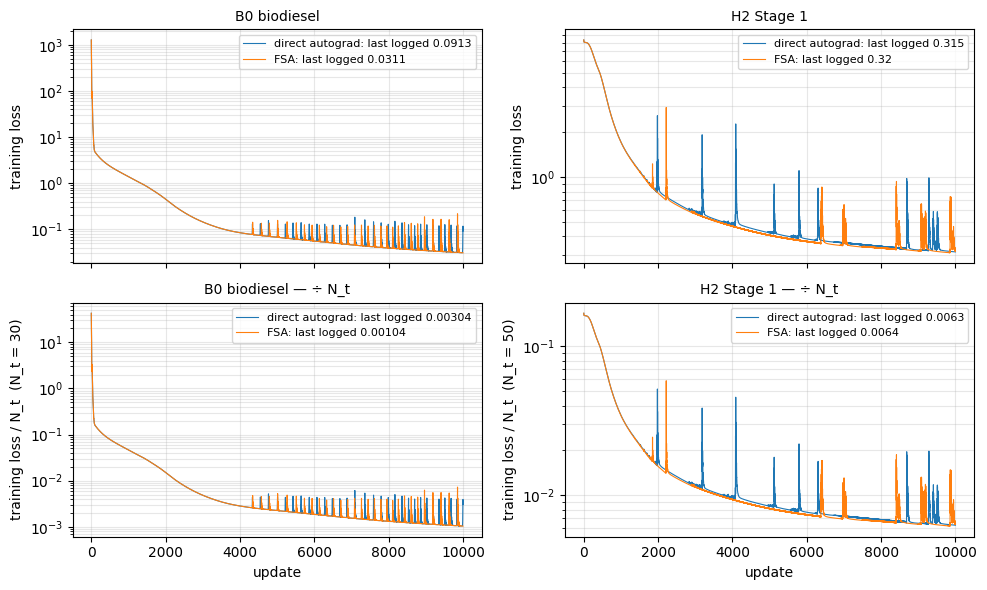

In [8]:
T = ROOT / "results/experiments/legacy/biodiesel/fsa/tables/biodiesel_B0_fsa_comparison.csv"
if T.exists():
    display(pd.read_csv(T)[["run", "train_mse_clean_full_trajectory", "test_mse_clean_full_trajectory",
                            "training_seconds"]]
            .rename(columns={"train_mse_clean_full_trajectory": "train MSE (full trajectory)",
                             "test_mse_clean_full_trajectory": "test MSE (full trajectory)",
                             "training_seconds": "training time [s]"}).set_index("run"))

n_t = {k: len(np.load(ROOT / f"chemkan/data/generated/{k}.npz")["t"]) for k in ("biodiesel", "hydrogen")}
pairs = [("B0 biodiesel", n_t["biodiesel"],
          "results/reproduction/legacy/biodiesel/chemkan/main/direct_autograd_seed0/history.csv",
          "results/experiments/legacy/biodiesel/fsa/fsa_seed0/history.csv"),
         ("H2 Stage 1", n_t["hydrogen"],
          "results/reproduction/legacy/hydrogen/chemkan/diagnostics/base_on_n4/stage1_seed0/history_stage1.csv",
          "results/experiments/legacy/hydrogen/fsa/stage1_fsa_seed0/history_stage1.csv")]
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex="col")
for c, (title, N, da, fsa) in enumerate(pairs):
    for r, div in enumerate((1, N)):
        ax = axes[r, c]
        for lab, f in (("direct autograd", da), ("FSA", fsa)):
            if (ROOT / f).exists():
                h = pd.read_csv(ROOT / f)
                ax.semilogy(h.epoch, h.total_loss / div, lw=0.8,
                            label=f"{lab}: last logged {h.total_loss.iloc[-1] / div:.3g}")
        ax.set_ylabel("training loss" if r == 0 else f"training loss / N_t  (N_t = {N})")
        ax.set_title(title if r == 0 else f"{title} — ÷ N_t", fontsize=10)
        ax.grid(alpha=.3, which="both"); ax.legend(fontsize=8)
    axes[1, c].set_xlabel("update")
plt.tight_layout()

### Hydrogen Stage 2, random initialization (H0): interim, FSA run incomplete

Direct autograd trained all 10,000 Stage-2 epochs. The FSA run's committed history ends at
epoch 5,970, so the two are compared only up to that horizon (dotted line). The right panel
zooms in on epochs 5,000–5,970. These are **not** benchmark results. By the current
~5,970-epoch horizon, the direct-autograd and FSA runs have reached very similar Stage-2
training-loss levels. The FSA run remains incomplete, so the thermodynamic/temperature
reproduction with FSA is not yet established.

The two runs start from their own Stage-1 checkpoints (FSA from `stage1_fsa_seed0`, direct
autograd from `base_on_n4/stage1_seed0`), so this is an end-to-end backend comparison, not a
controlled Stage-2-only ablation. The norm-matched (Hnorm1) FSA run stopped much earlier and
is not plotted.


,last epoch logged,loss at epoch 5970,"median, epochs 5000–5970"
backend,,,
direct autograd,9999,2.1683,2.1739
FSA (incomplete),5970,2.1526,2.1571


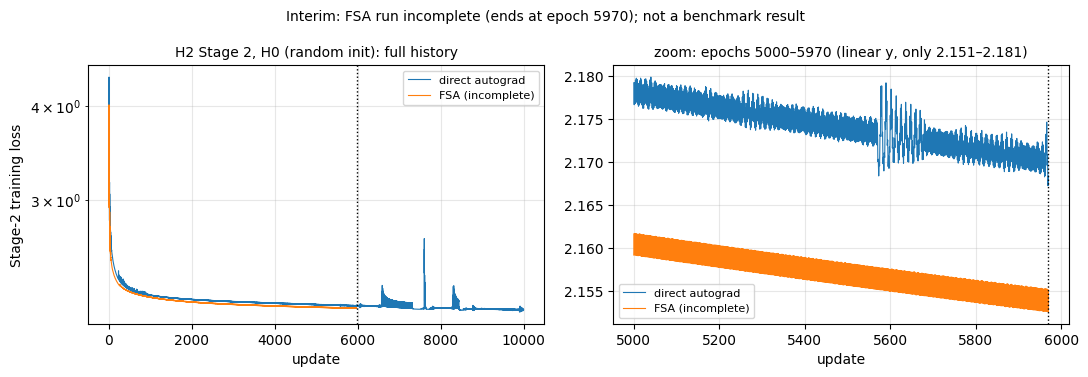

In [ ]:
H2S2 = {"direct autograd": "results/reproduction/legacy/hydrogen/chemkan/diagnostics/base_on_n4/random_stage2_10000_seed0/history_stage2.csv",
        "FSA (incomplete)": "results/experiments/legacy/hydrogen/fsa/random_stage2_10000_fsa_seed0/history_stage2.csv"}
hist = {k: pd.read_csv(ROOT / f) for k, f in H2S2.items()}
horizon = int(hist["FSA (incomplete)"].epoch.max())            # last epoch FSA reached
window = (5000, horizon)

rows = []
for k, h in hist.items():
    at = h.loc[h.epoch == horizon, "total_loss"].item()
    med = h.loc[h.epoch.between(*window), "total_loss"].median()
    rows.append({"backend": k, "last epoch logged": int(h.epoch.max()),
                 f"loss at epoch {horizon}": at, f"median, epochs {window[0]}–{window[1]}": med})
display(pd.DataFrame(rows).set_index("backend").round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for k, h in hist.items():
    axes[0].semilogy(h.epoch, h.total_loss, lw=0.8, label=k)
    z = h[h.epoch.between(*window)]
    axes[1].plot(z.epoch, z.total_loss, lw=0.8, label=k)
for ax in axes:
    ax.axvline(horizon, color="k", ls=":", lw=1)
    ax.set_xlabel("update"); ax.grid(alpha=.3, which="both"); ax.legend(fontsize=8)
axes[0].set_ylabel("Stage-2 training loss")
axes[0].set_title("H2 Stage 2, H0 (random init): full history", fontsize=10)
lo, hi = axes[1].get_ylim()
axes[1].set_title(f"zoom: epochs {window[0]}–{window[1]} (linear y, only {lo:.3f}–{hi:.3f})", fontsize=10)
fig.suptitle(f"Interim: FSA run incomplete (ends at epoch {horizon}); not a benchmark result", fontsize=10)
plt.tight_layout()
